<a href="https://colab.research.google.com/github/negilbabu/Heart-Disease-Prediction-Ai-/blob/dev/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update
!apt-get install git

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

# Importing necessory Libraries

In [83]:
!pip install scikit-learn==1.3.0 --quiet
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# About the Dataset

In [84]:
from tabulate import tabulate

data = [
    ["age", "Age of the patient in years"],
    ["sex", "Gender of the patient (0 = male, 1 = female)"],
    ["cp", "Chest pain type: 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic"],
    ["trestbps", "Resting blood pressure in mmHg"],
    ["chol", "Serum cholesterol in mg/dl"],
    ["fbs", "Fasting blood sugar level, categorized as above 120 mg/dl (1 = true, 0 = false)"],
    ["restecg", "Resting ECG results: 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy"],
    ["thalach", "Maximum heart rate achieved during a stress test"],
    ["exang", "Exercise-induced angina (1 = yes, 0 = no)"],
    ["oldpeak", "ST depression induced by exercise relative to rest"],
    ["slope", "Slope of peak exercise ST segment: 0: Upsloping, 1: Flat, 2: Downsloping"],
    ["ca", "Number of major vessels (0-4) colored by fluoroscopy"],
    ["thal", "Thallium stress test result: 0: Normal, 1: Fixed defect, 2: Reversible defect, 3: Not described"],
    ["target", "Heart disease status (0 = no disease, 1 = presence of disease)"]
]

print(tabulate(data, headers=["Feature", "Description"], tablefmt="grid"))


+-----------+-------------------------------------------------------------------------------------------------+
| Feature   | Description                                                                                     |
+===========+=================================================================================================+
| age       | Age of the patient in years                                                                     |
+-----------+-------------------------------------------------------------------------------------------------+
| sex       | Gender of the patient (0 = male, 1 = female)                                                    |
+-----------+-------------------------------------------------------------------------------------------------+
| cp        | Chest pain type: 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic    |
+-----------+-------------------------------------------------------------------------------------------

# Data Exploration

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/abdelDebug/Heart-Disease-Data/refs/heads/main/heart_disease.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [85]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


Statistical summary

In [86]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [87]:
df.shape

(303, 14)

In [88]:
df["target"].unique()

array([0, 1])

# Data Preprocessing

In [89]:
# Stripping of column names
df.columns = df.columns.str.strip()

In [90]:
print("Checking for null values....")
count = df.isnull().sum()
for col, null_count in count.items():
    if null_count > 0:
        print(f"Column '{col}' has {null_count} null values. Removing null values...")
        df = df.dropna(subset=[col])

    else:
        print(f"Column '{col}' has no null values.")
print("Shape of dataframe", df.shape)

Checking for null values....
Column 'age' has no null values.
Column 'sex' has no null values.
Column 'cp' has no null values.
Column 'trestbps' has no null values.
Column 'chol' has no null values.
Column 'fbs' has no null values.
Column 'restecg' has no null values.
Column 'thalach' has no null values.
Column 'exang' has no null values.
Column 'oldpeak' has no null values.
Column 'slope' has no null values.
Column 'ca' has no null values.
Column 'thal' has no null values.
Column 'target' has no null values.
Shape of dataframe (303, 14)


In [91]:
print("Checking for duplicated rows:")
duplicated_rows = df.duplicated()
print(f"Total duplicated rows: {duplicated_rows.sum()}")

if duplicated_rows.any():
    df_removed_duplicates = df.drop_duplicates()
    print("Shape of dataframe after removing duplicates", df_removed_duplicates.shape)

Checking for duplicated rows:
Total duplicated rows: 0


In [92]:
categorical_data= df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']]
numerical = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]

# **Outlier Analysis**
For continuous features

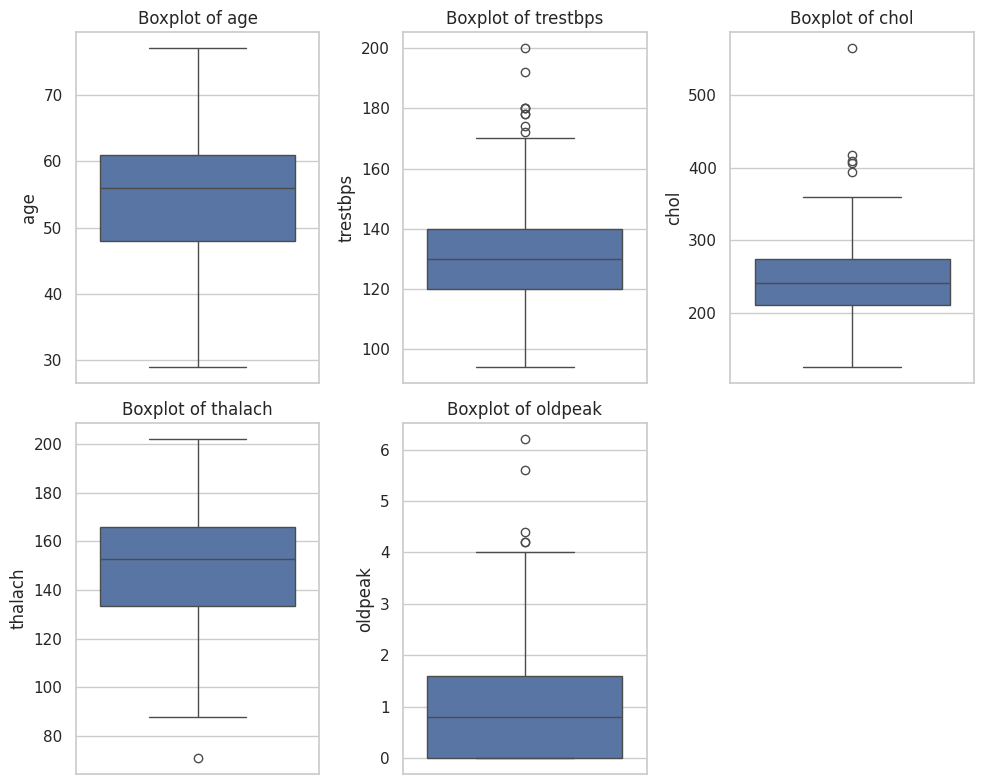

In [95]:
fig, axs = plt.subplots(2, 3, figsize=(10, 8))
axs = axs.flatten()

for i, col in enumerate(numerical.columns):
    sns.boxplot(data=df, y=col, ax=axs[i])
    axs[i].set_title(f'Boxplot of {col}')

fig.delaxes(axs[len(numerical.columns)])

plt.tight_layout()
plt.show()

Outliers are present for trestbps, chol, thalach and oldpeak. Among these trestbps and chol. We have to handle the outliers before further steps.

Treating Outliers for trestbps

In [96]:
# Calculate IQR and filter out outliers
Q1 = df.trestbps.quantile(0.25)
Q3 = df.trestbps.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['trestbps'] > max_limit].shape[0]

total_data_points = df.shape[0]
percentage_outliers = (outlier_count / total_data_points) * 100
print(f"Percentage of outliers in 'trestbps': {percentage_outliers:.2f}%")

IQR: 20.0
Min Limit: 90.0
Max Limit: 170.0
Percentage of outliers in 'trestbps': 2.97%


In [97]:
df.loc[df['trestbps'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
83,68,1,2,180,274,1,2,150,1,1.6,1,0,3,1
126,56,0,3,200,288,1,2,133,1,4.0,2,2,3,1
172,59,0,3,174,249,0,0,143,1,0.0,1,0,1,1
183,59,1,0,178,270,0,2,145,0,4.2,2,0,3,0
188,54,1,1,192,283,0,2,195,0,0.0,0,1,3,1
201,64,0,3,180,325,0,0,154,1,0.0,0,0,1,0
213,66,0,3,178,228,1,0,165,1,1.0,1,2,3,1
231,55,0,3,180,327,0,1,117,1,3.4,1,0,1,1


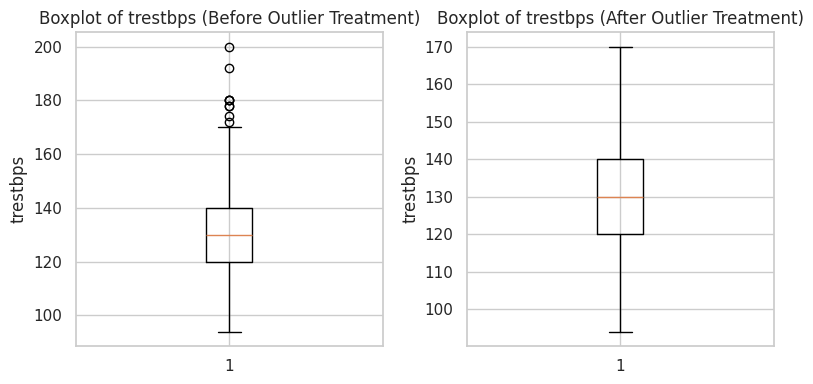

In [98]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on trestbps
plt.subplot(1, 2, 1)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (Before Outlier Treatment)")
plt.ylabel("trestbps")


# Imputation of outlier
df.loc[df['trestbps'] > max_limit ,'trestbps']=np.median(df['trestbps'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (After Outlier Treatment)")
plt.ylabel("trestbps")

# Adjust layout and display
plt.tight_layout()
plt.show()

We have decided to treat the outlier using imputation because we only have 303 data and removing a significant data from dataset may affect the model.
After imputation, no outlier is present in trestbps

In [99]:
count_outliers = df.loc[df['trestbps'] > max_limit].shape[0]
print(f"Number of rows with 'trestbps' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'trestbps' greater than 170.0(max limit) =  0


Treating outliers for Chol

In [100]:
# Calculate IQR and filter out outliers
Q1 = df.chol.quantile(0.25)
Q3 = df.chol.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['chol'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'chol': {percentage_outliers:.2f}%")

IQR: 64.0
Min Limit: 115.0
Max Limit: 371.0
Percentage of outliers in 'chol': 1.65%


In [17]:
df.loc[df['chol'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,65,0,2,140,417,1,2,157,0,0.8,0,1,1,0
121,63,0,3,150,407,0,2,154,0,4.0,1,3,3,1
152,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
173,62,0,3,140,394,0,2,157,0,1.2,1,0,1,0
181,56,0,3,134,409,0,2,150,1,1.9,1,2,3,1


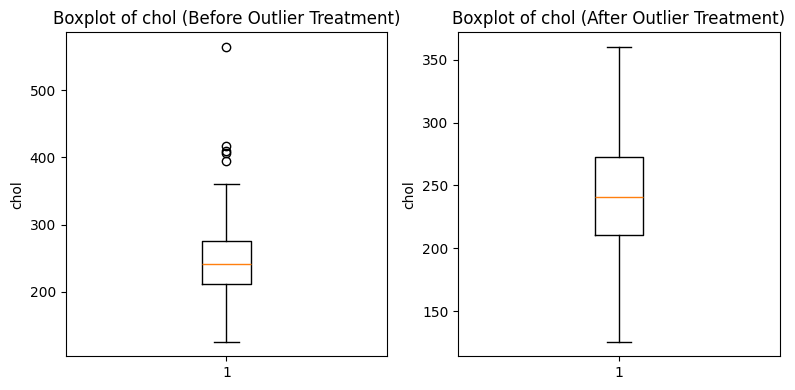

In [18]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on chol
plt.subplot(1, 2, 1)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (Before Outlier Treatment)")
plt.ylabel("chol")


# Imputation of outlier
df.loc[df['chol'] > max_limit ,'chol']=np.median(df['chol'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (After Outlier Treatment)")
plt.ylabel("chol")

# Adjust layout and display
plt.tight_layout()
plt.show()

Like we did on trestbps, here also implimented the imputation for handling the outliers in chol. After imputation there is no outlier in chol.

In [19]:
count_outliers = df.loc[df['chol'] > max_limit].shape[0]
print(f"Number of rows with 'chol' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'chol' greater than 371.0(max limit) =  0


In [20]:
# Calculate IQR and filter out outliers
Q1 = df.thalach.quantile(0.25)
Q3 = df.thalach.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['thalach'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'thalach': {percentage_outliers:.2f}%")

IQR: 32.5
Min Limit: 84.75
Max Limit: 214.75
Percentage of outliers in 'thalach': 0.00%


In [21]:
# Calculate IQR and filter out outliers
Q1 = df.oldpeak.quantile(0.25)
Q3 = df.oldpeak.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['oldpeak'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'oldpeak': {percentage_outliers:.2f}%")

IQR: 1.6
Min Limit: -2.4000000000000004
Max Limit: 4.0
Percentage of outliers in 'oldpeak': 1.65%


In [22]:
df.loc[df['oldpeak'] > max_limit]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
91,62,0,3,160,164,0,2,145,0,6.2,2,3,3,1
123,55,1,3,140,217,0,0,111,1,5.6,2,0,3,1
183,59,1,0,130,270,0,2,145,0,4.2,2,0,3,0
191,51,1,3,140,298,0,0,122,1,4.2,1,3,3,1
285,58,1,3,114,318,0,1,140,0,4.4,2,3,2,1


Here only 5 attributes has values greater than maximum limit. But when we analyze the medical data, for a person having multiple blockages for heart vessels, it is possible to have such extreme values. By considering that we can ignore oldpeak outliers here.

# EDA and Data visualization

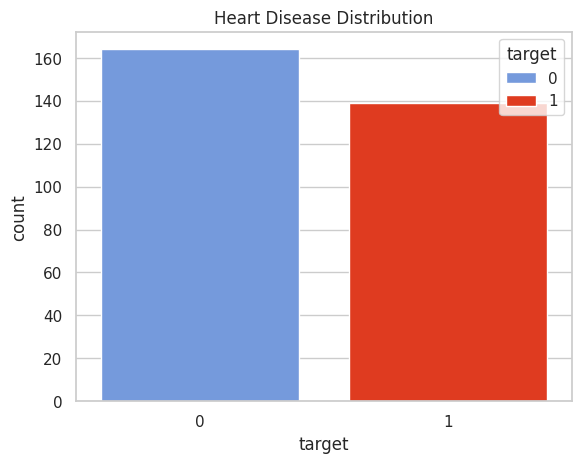

In [78]:
sns.set(style="whitegrid")

sns.countplot(x='target',hue='target', data=df,palette=['#6495ED', '#FF2400'])
plt.title('Heart Disease Distribution')

plt.show()

Heart disease distribution is almost equally distributed.
People with heart disease are less than those without heart disease

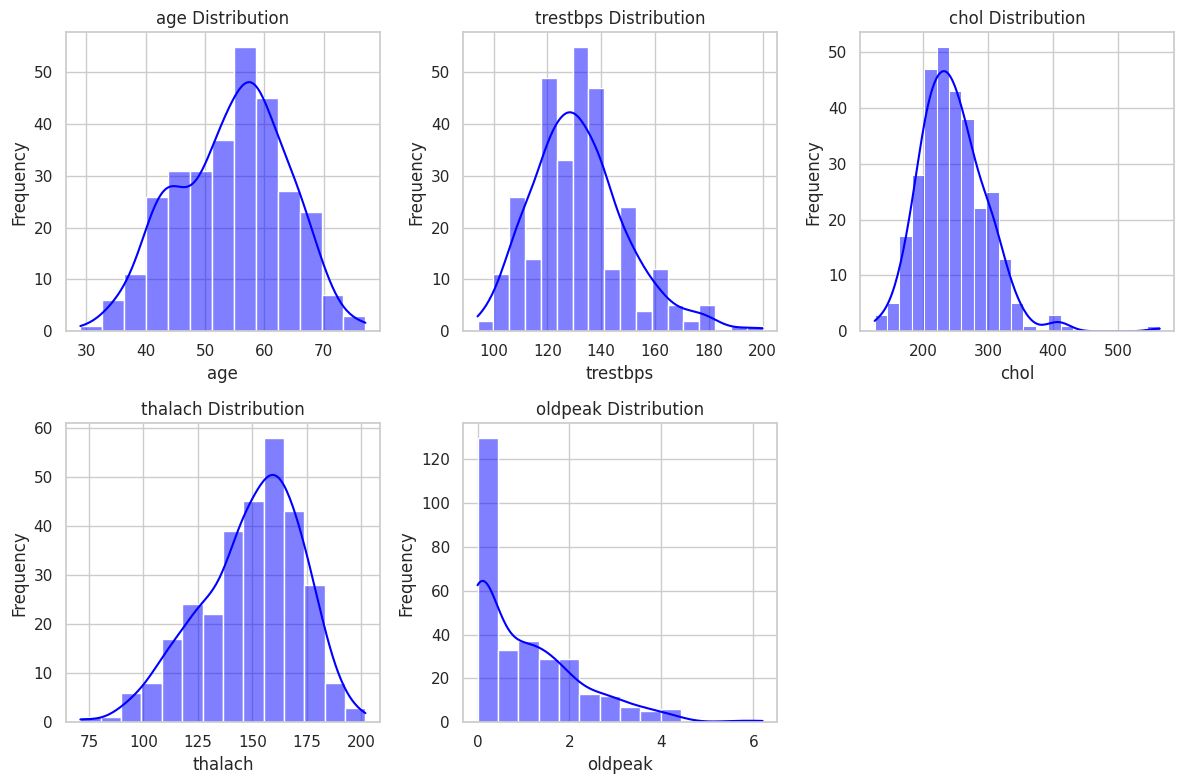

In [32]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(numerical, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[column], kde=True, color='blue')
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Key Insights**



1.   Age: Age distribution almost normal with a slight positive skewness. Clearly it shows number of older individuals are higher than younger individuals.

2.   trestbps (Resting Blood Pressure): The trestbps distribution is almost normal with slight positive skewness which means almost people have resting bp within a range but there are also some idividuals with higher values.

3.   chol (Cholesterol):  Similar to the previous two, the cholesterol distribution is approximately normal with a slight positive skew.

4.   thalach (Maximum Heart Rate Achieved): The distribution of maximum heart rate achieved is approximately normal with a slight negative skew.  This suggests that most individuals can achieve a certain range of maximum heart rate, with a few individuals having significantly lower maximum heart rates.


5.   oldpeak (ST Depression Induced by Exercise Relative to Rest): The distribution of ST depression induced by exercise is positively skewed.








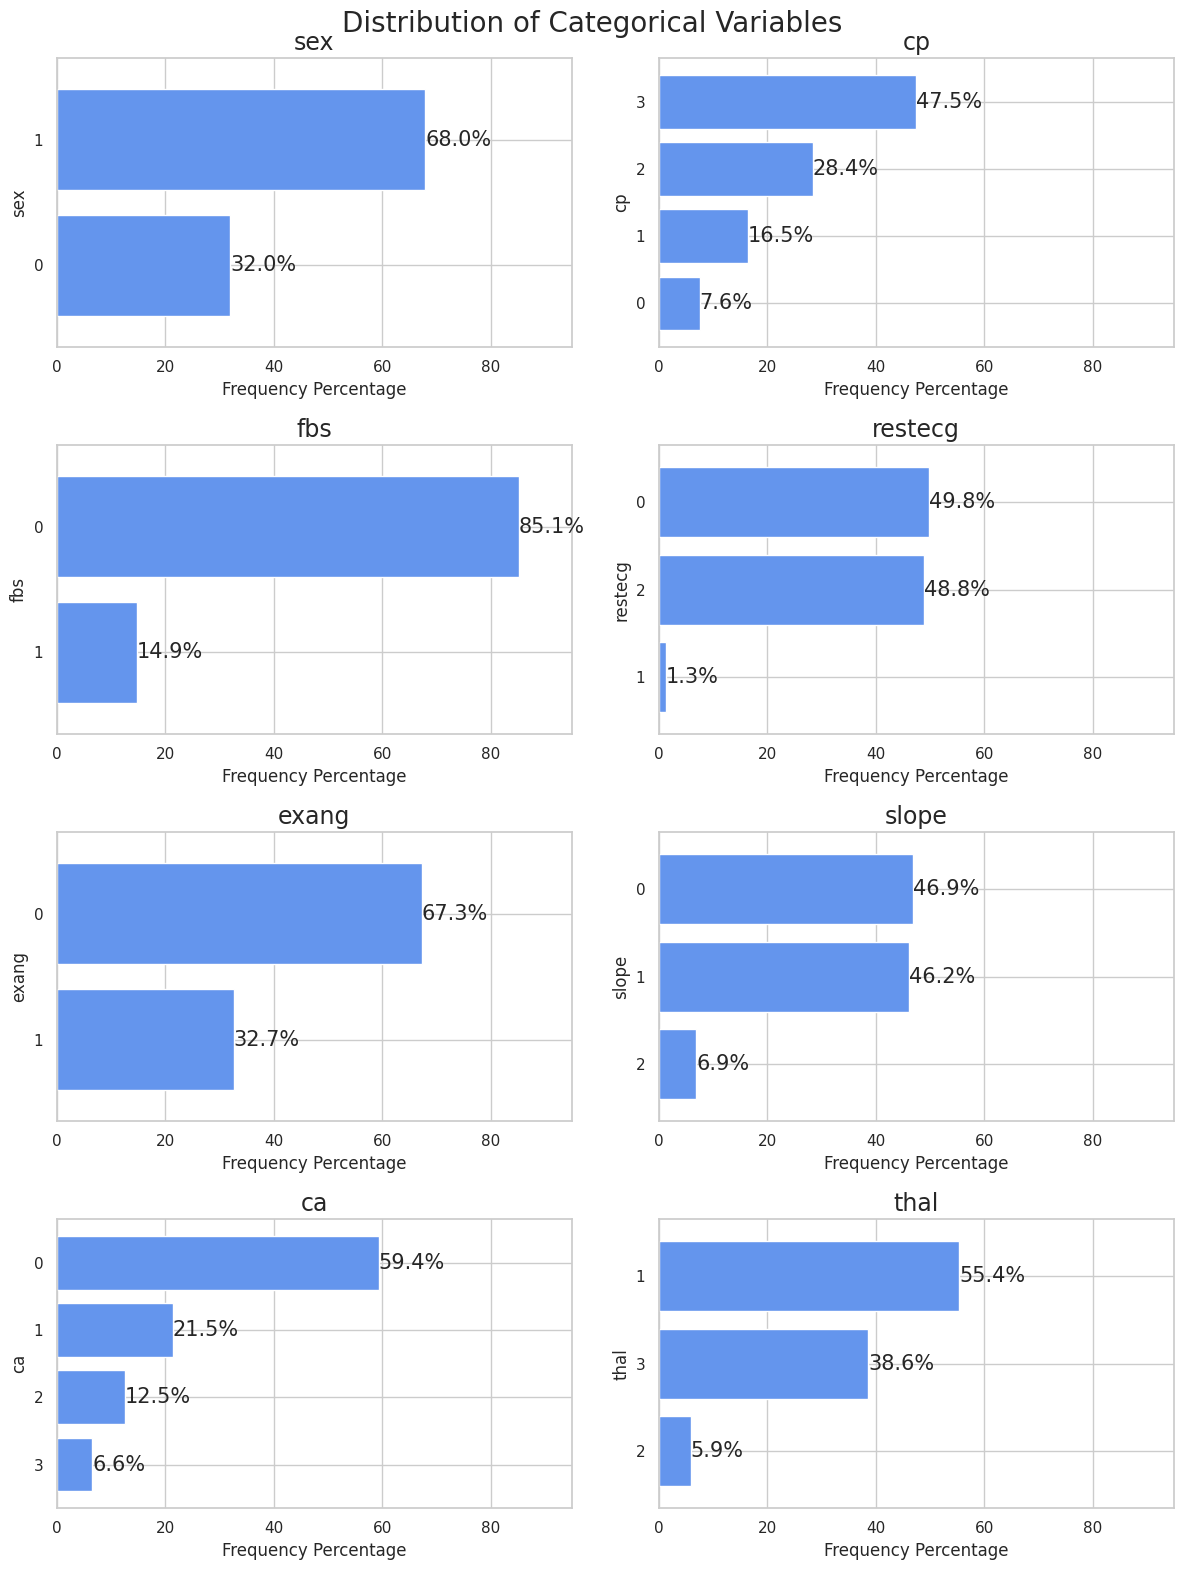

In [67]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))

for i, col in enumerate(categorical_data):
    row = i // 2
    col_idx = i % 2

    # Calculate frequency percentages
    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()

    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='#6495ED')

    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, va='center')

    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=17)


plt.suptitle('Distribution of Categorical Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

**Key Insights**


1.   Sex: Number of females is higer than men in our dataset

2.   cp (chest pain): Chest pain type 3 (Asymptomatic) is the most frequent, accounting for around 47.5% of the cases.

3.   fbs (Fasting Blood Sugar): The majority of individuals (85.1%) have fasting blood sugar levels below 120 mg/dl.

4.   Resting ECG(restecg): The most frequent resting ECG result is category 0 (Normal), and category 1(ST-T wave abnormality)occurring in approximately 49% of the cases. The  category 2 (Left ventricular hypertrophy) is the least common occuring restecg.

5.   exang(Exercise-induced Angina): The majority of patients (67.3%) do not experience exercise-induced angina (exang = 0).

6.   slope: The most common slope is 1 (Flat), occurring in 46.2% of the cases.
Slope 0 (Upsloping) is also common, occurring in 46.9% of the cases.
Slope 2 (Downsloping) is the least frequent, occurring in only 6.9% of the cases.

7.   ca(Number of Major Vessels Colored by Fluoroscopy): The most common category is 0 (no major vessels colored), occurring in 59.4% of the cases.
The remaining categories (1, 2, and 3) have lower frequencies, with category 3 (three major vessels colored) being the least common.

8.   thal(Thallium Stress Test Result): The most common thallium stress test result is 1 (Fixed defect), occurring in 55.4% of the cases.









In [101]:
# Mapping gender values to labels
gender_mapping = {0: 'Male', 1: 'Female'}
df_mapped = df.copy()
df_mapped['Gender'] = df_mapped['sex'].map(gender_mapping)

gender_counts = df_mapped['Gender'].value_counts()
total_males = gender_counts.get('Male', 0)
total_females = gender_counts.get('Female', 0)

# Count males and females with heart disease (target = 1)
gender_disease_counts = df_mapped[df_mapped['target'] == 1]['Gender'].value_counts()
males_with_disease = gender_disease_counts.get('Male', 0)
females_with_disease = gender_disease_counts.get('Female', 0)

# Calculate the proportions (heart disease cases among total males and females)
female_ratio = females_with_disease / total_females if total_females > 0 else 0
male_ratio = males_with_disease / total_males if total_males > 0 else 0

# Calculate the percentages (males and females among total heart disease cases)
total_with_disease = males_with_disease + females_with_disease
male_percentage = (males_with_disease / total_with_disease) * 100 if total_with_disease > 0 else 0
female_percentage = (females_with_disease / total_with_disease) * 100 if total_with_disease > 0 else 0

print(f"Heart Disease Proportion - Females: {female_ratio:.2%}")
print(f"Heart Disease Proportion - Males: {male_ratio:.2%}")
print(f"Percentage of Males among Heart Disease Cases: {male_percentage:.2f}%")
print(f"Percentage of Females among Heart Disease Cases: {female_percentage:.2f}%")


Heart Disease Proportion - Females: 55.34%
Heart Disease Proportion - Males: 25.77%
Percentage of Males among Heart Disease Cases: 17.99%
Percentage of Females among Heart Disease Cases: 82.01%


**Exploration of Categorical Data**

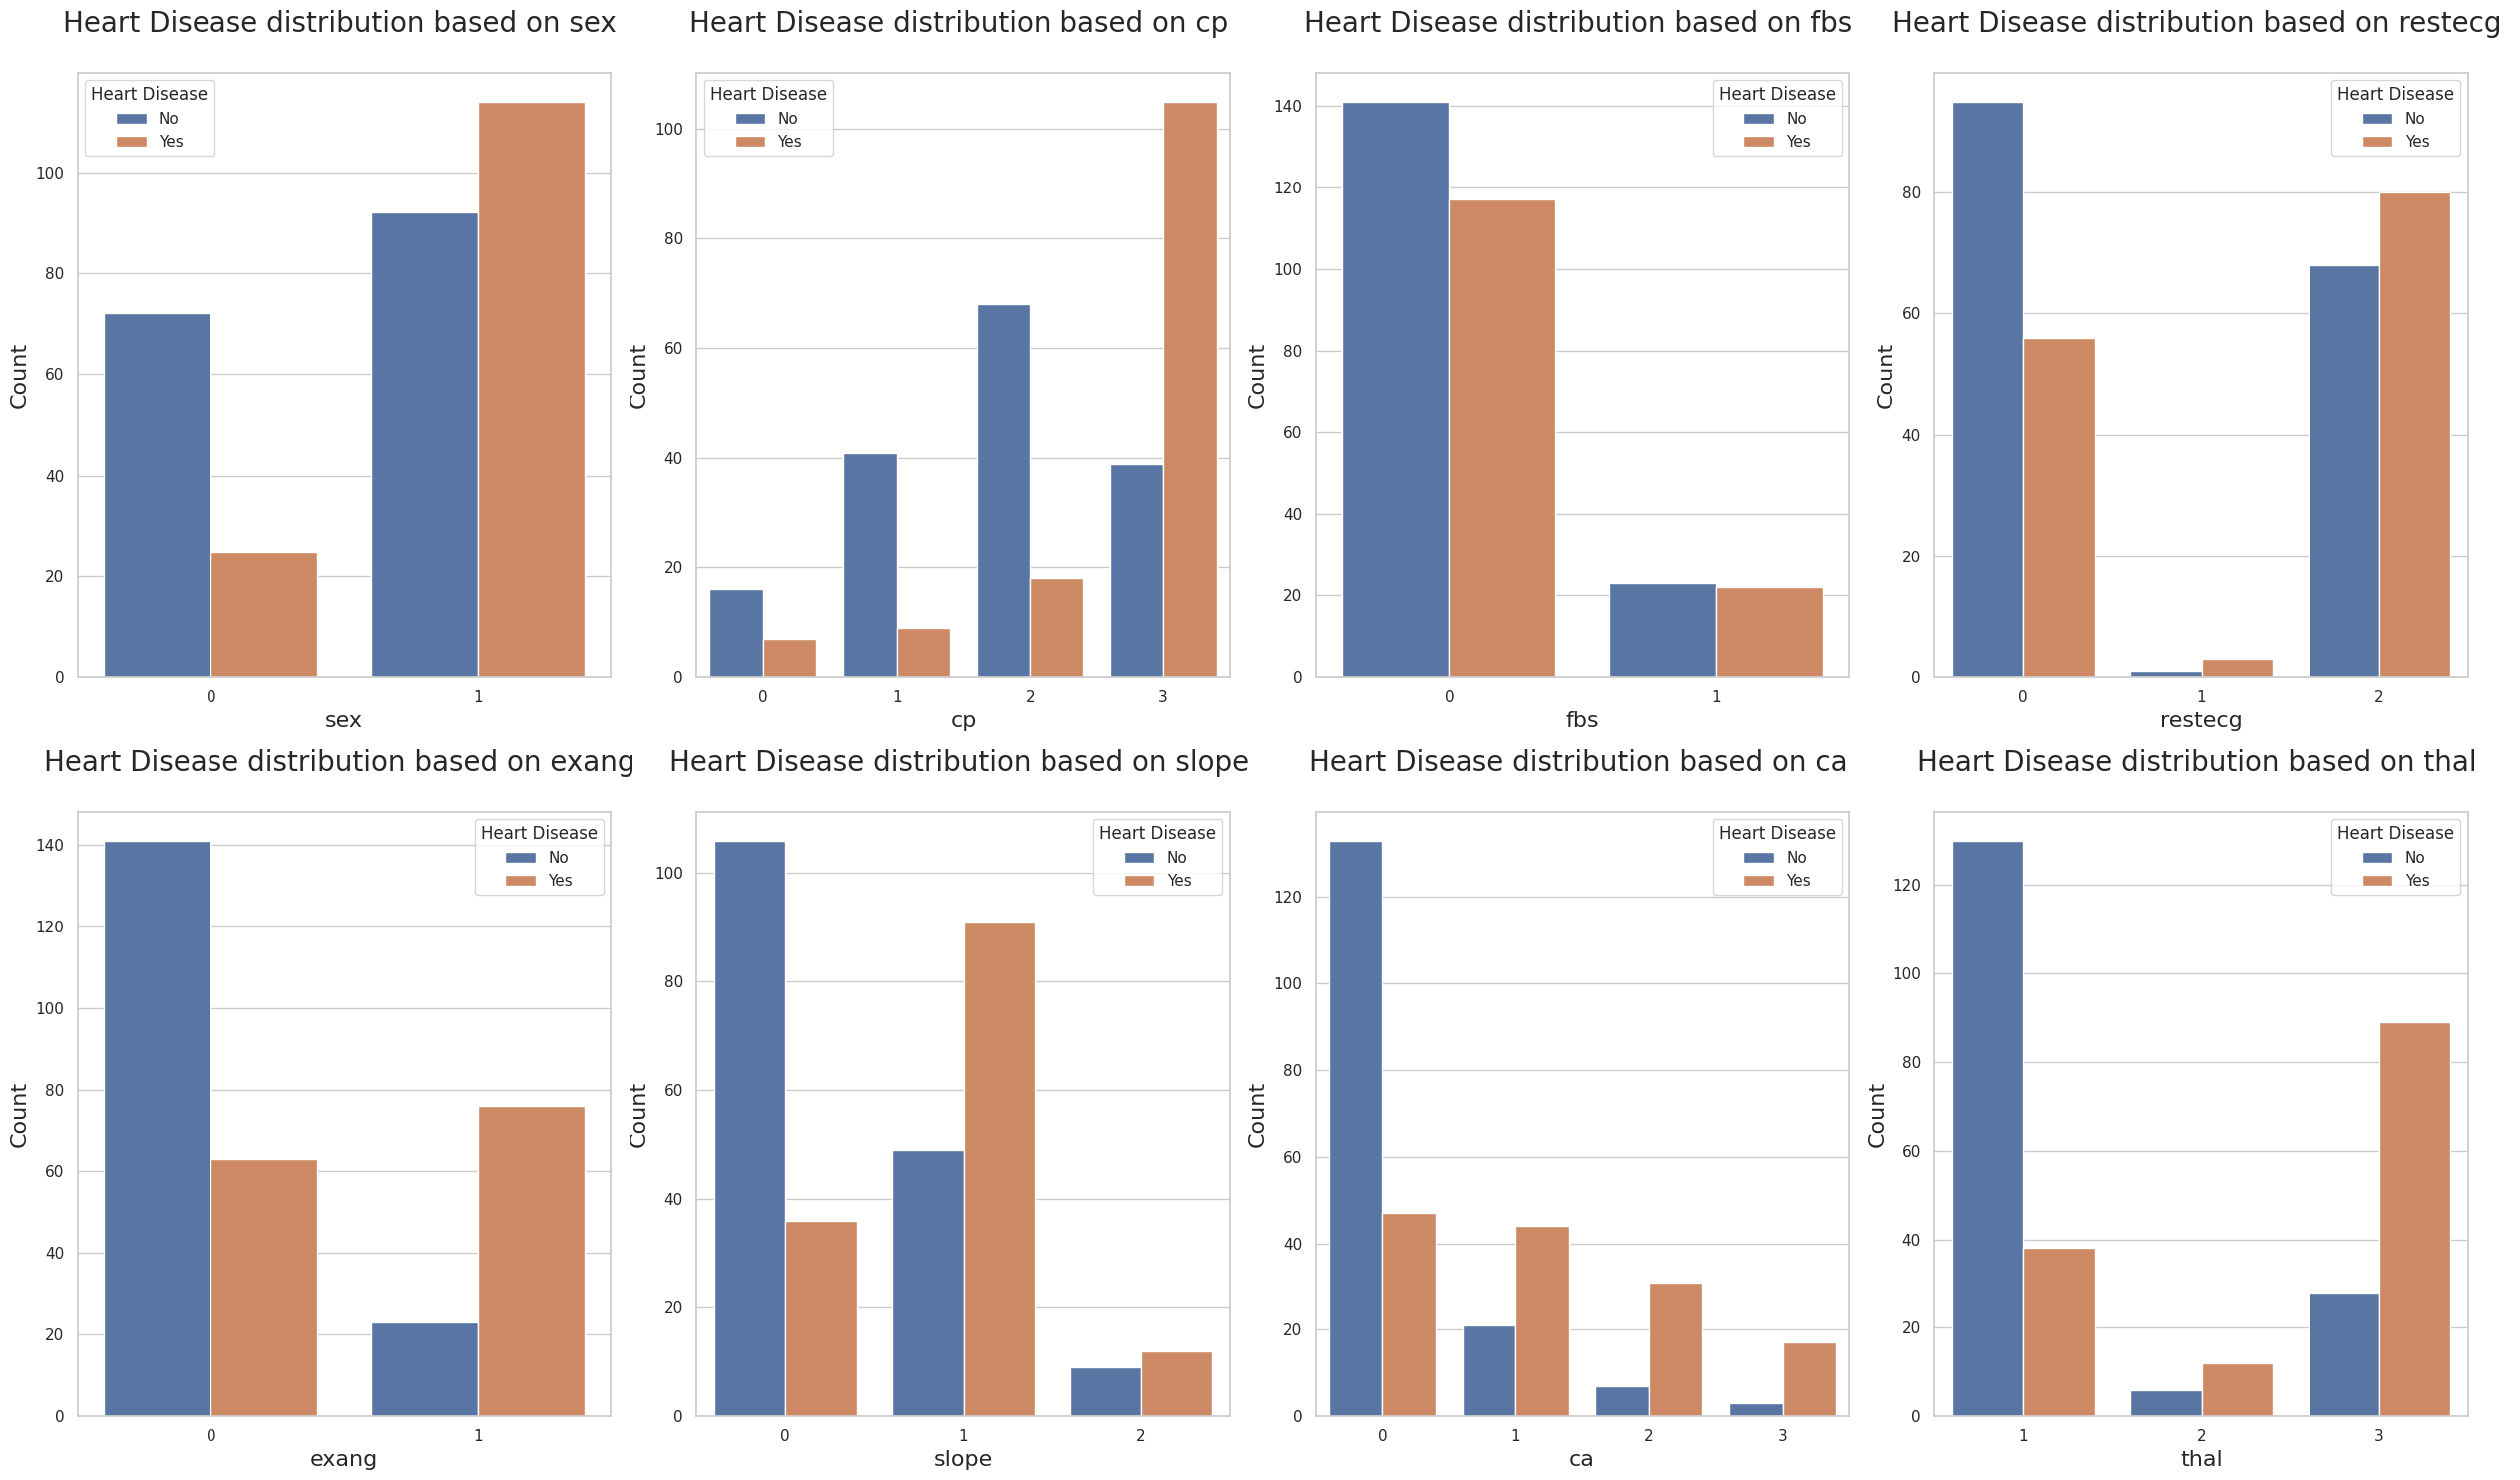

In [102]:
plt.figure(figsize=(25, 15))
plotno = 1

for column in categorical_data.columns:
    if plotno <= 8:
        plt.subplot(2, 4, plotno)
        sns.countplot(x=column, hue='target', data=df)
        plt.xlabel(column, fontsize=16)
        plt.ylabel('Count', fontsize=16)
        plt.title(f'Heart Disease distribution based on {column} \n', fontsize=20)
        plt.legend(title='Heart Disease', labels=['No','Yes'])
        plotno += 1

plt.tight_layout()
plt.show()


**Key Observations**

The distribution of heart disease cases is not uniform across all categories in the dataset .

**Heart disease vs sex**

* Plot shows that heart diseases are more often in females when comparing to males.
* Heart Disease Proportion - Females: 55.34%
Heart Disease Proportion - Males: 25.77%
Percentage of Males among Heart Disease Cases: 17.99%
Percentage of Females among Heart Disease Cases: 82.01%


**Heart disease vs Chest pain(cp)**

*   The people with chest pain type 3(Asymptomatic) and 2(Non anginal pain) has the higher chances of having a heart disease while comparing with others.



**Heart disease vs Fasting Blood Sugar(fbs)**


*   Relatively even distribution among heart disease and no heart disease.
*   People without fbs(less than 120 mg) has less chance of having heart disease, those who has fbs(greater than 120mg) has almost equal chances of having heart disease.

Heart Disease vs Resting ECG(restecg)


*   Majority of individuals having normal resting ECG do not have heart disease
*   Restecg values 1(Having ST-T wave abnormality) and 2(Showing probable or definite left ventricular hypertrophy) having more heart diseases.


**Heart Disease vs Exercise induced angina(exang)**


*    Individuals who experience exercise-induced angina (exang=1) have a significantly higher proportion of heart disease compared to those who do not (exang=0).



**Heart Disease vs slope**


*    Individuals having downsloping ST segment during exercise have a higher proportion of heart disease compared to those with upsloping (slope=0) or flat (slope=1) ST segments.



Heart Disease vs Ca(Major vessels colours)

*   Heart vessels having colours 3 appears to have more heart disease rate while comparing with other.
the number of major vessels colored by fluoroscopy

*   Which means as the Heart vessels color(ca) increases, the proportion of individuals with heart disease also tends to increase.


**Heart Disease vs thallium(thal)**


*   Individuals with a reversible defect (thal = 2) or fixed defect (thal = 1) in the thallium stress test have a higher proportion of heart disease compared to those with normal results (thal = 0) or those with results not described (thal = 3).


Exploration of numerical data

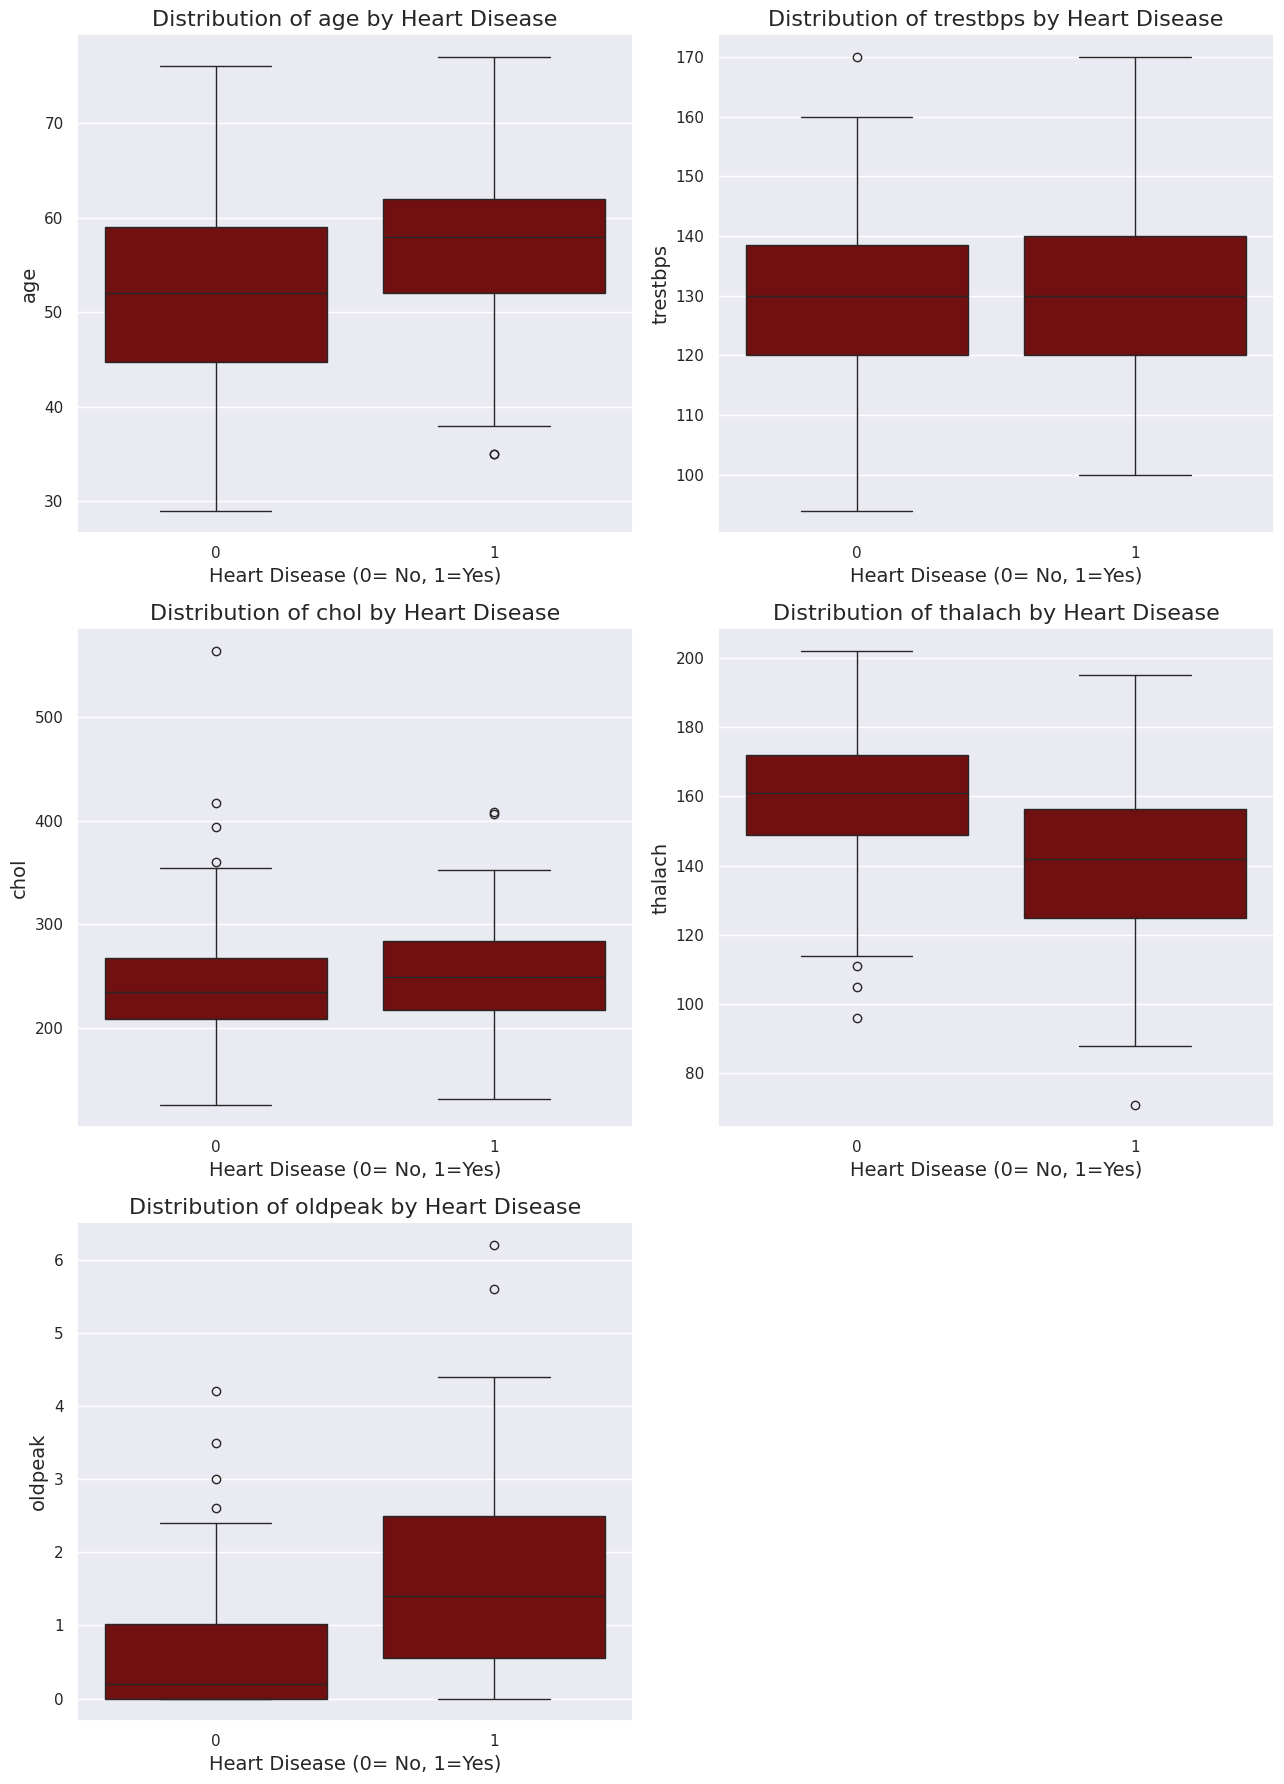

In [103]:
sns.set_style('darkgrid')
plt.figure(figsize=(13, 18))
plotno = 1

for column in numerical.columns:
    if plotno <= 5:
        plt.subplot(3, 2, plotno)

        sns.boxplot(data=df, y=column, x='target', color='maroon')

        plt.ylabel(column, fontsize=14)
        plt.xlabel('Heart Disease (0= No, 1=Yes)', fontsize=14)
        plt.title(f'Distribution of {column} by Heart Disease', fontsize=16)

        plotno += 1

plt.tight_layout()
plt.show()


**Key Observations**

Heart Disease vs Age


*   The median age for individuals with heart disease is  slightly higher than those without.

Heart Disease vs Resting blood pressure(trestbps)


*   The median resting blood pressure for individuals with heart disease seems to be slightly higher than those without.



Heart Disease vs Cholestrol(chol)


*   The median cholesterol level for individuals with heart disease appears to be slightly higher than those without.



Heart Disease vs Max heart rate(thalach)


*   The median maximum heart rate achieved appears to be slightly lower for individuals with heart disease compared to those without.



Heart Disease vs ST depression induced by exercise relative to rest(oldpeak)


*   The median ST depression induced by exercise relative to rest (oldpeak) is higher for individuals with heart disease compared to those without.




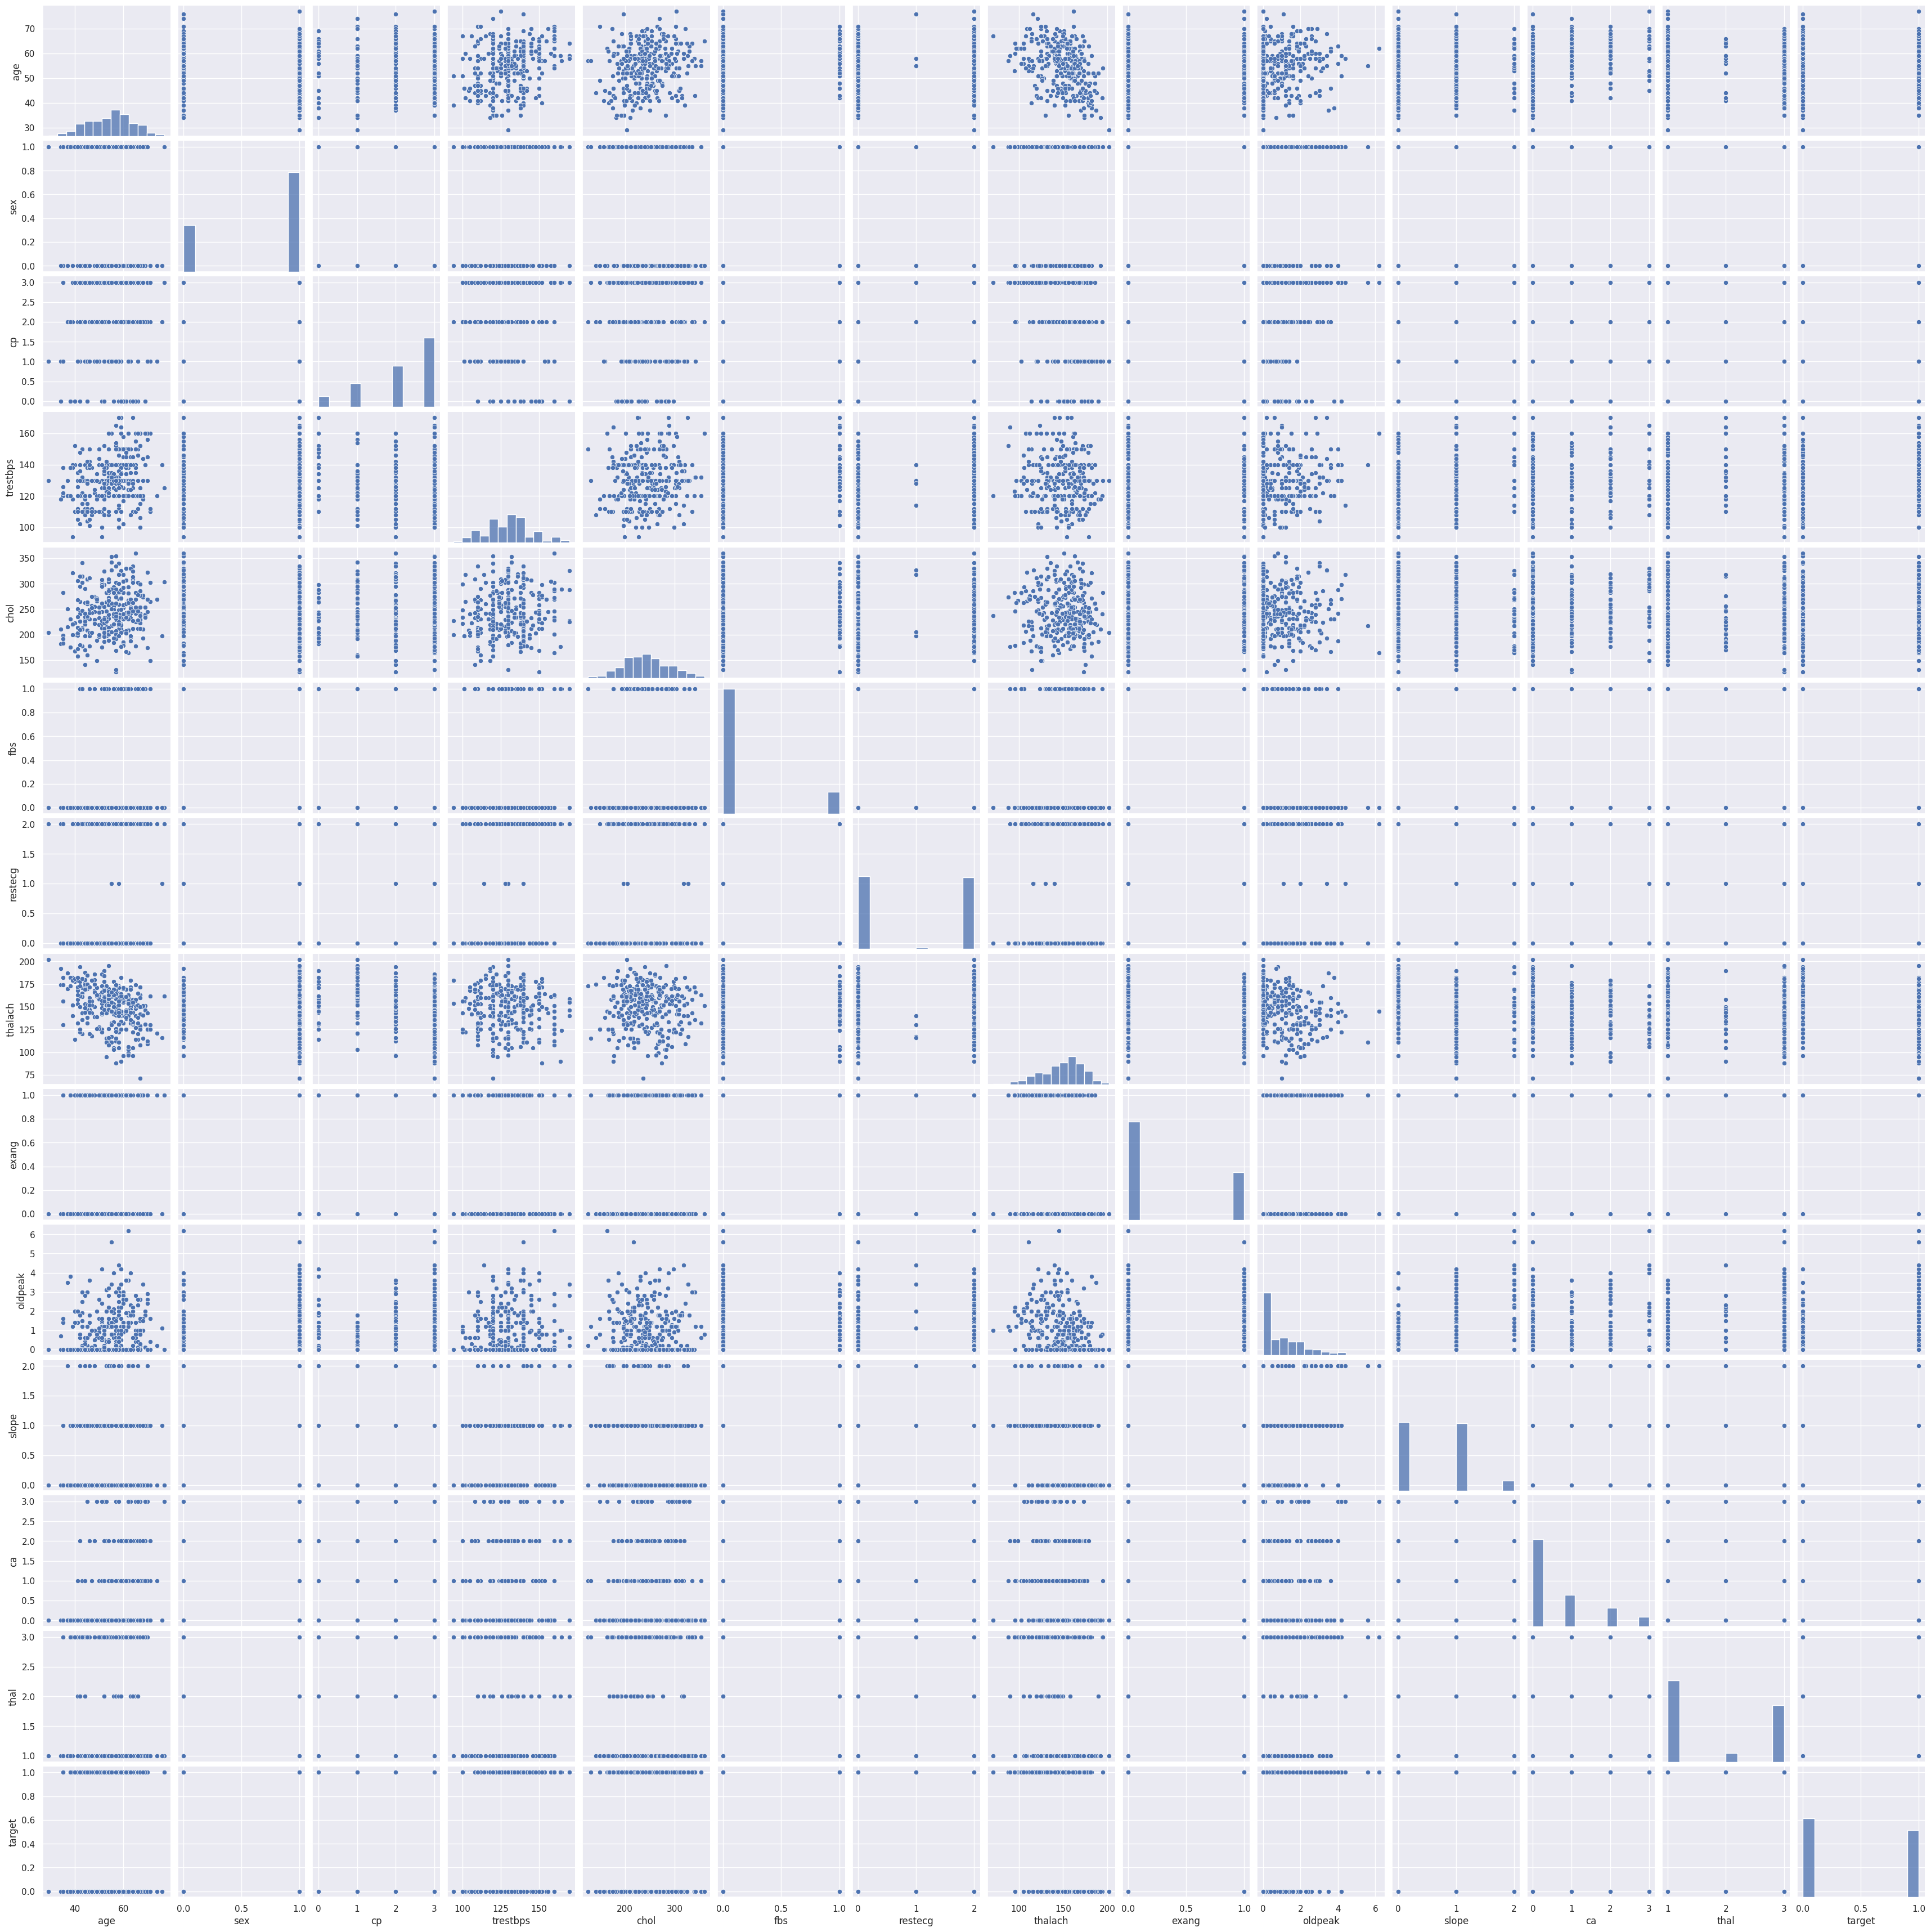

In [36]:
sns.pairplot(df)
plt.show()

# Correlation Heatmap

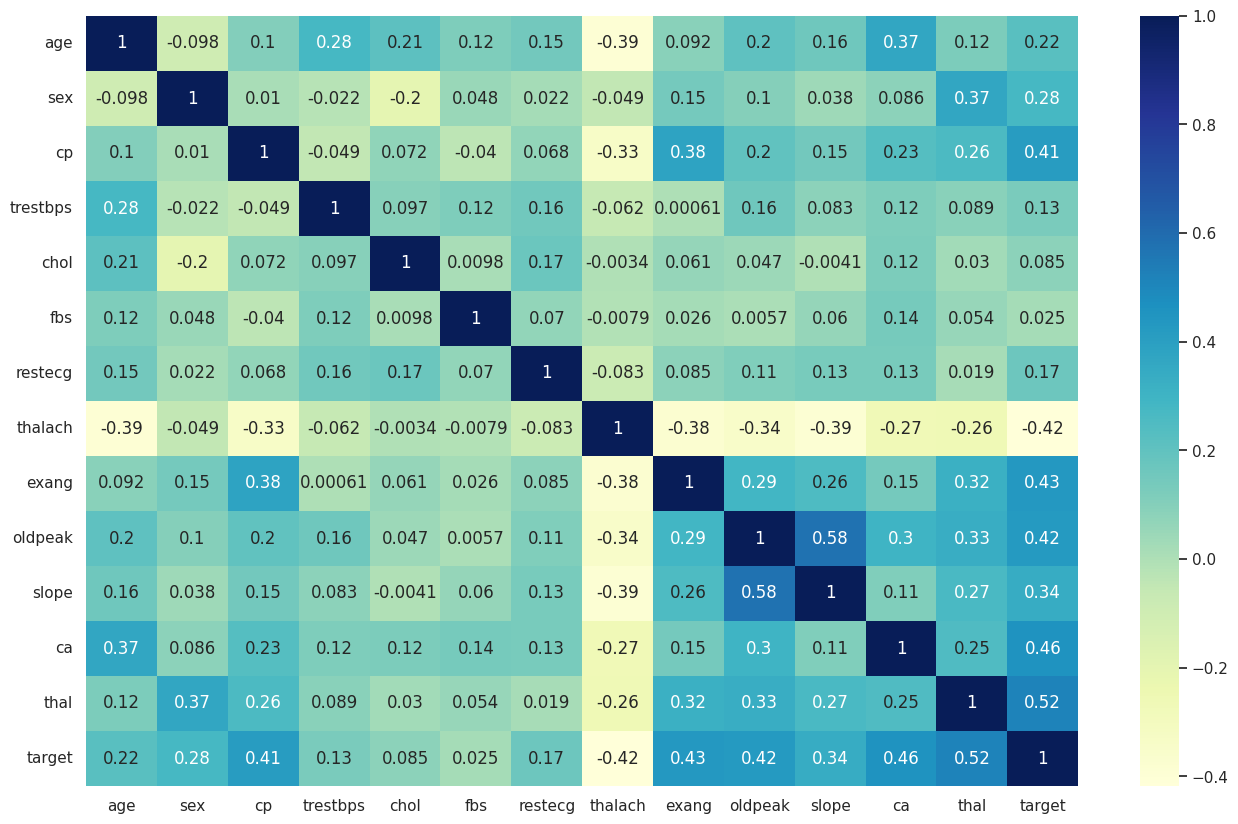

In [104]:
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), annot = True, cmap="YlGnBu")
plt.show()

**Key Insights**


*   thal, ca, cp, oldpeak, exang shows some strong positive correlation with the target varible which means that these attributes are significantly associated with the risk of heart disease.
*   Also thalach shows a negative correlation suggests that lower heart rate are more likely to have heart diseases.

*   age and trestbps shows a moderate positive correlation with target.





# Model Selection and Training

In [5]:
# Define the features (x) and the output labels (y)
x = df.drop(columns=['target'])
y = df['target']

In [6]:
# We specify this so that the train and test data set always have the same rows, respectively
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify=y)

**Feature scaling**

* Scaling ensures that all features contribute equally to the model's decision rather than being dominated by features with larger magnitudes. Here we are using standard scaler and it trasform the distribution with a mean of 0 and standard deviation of 1.
* The reson for scaling is that we are using the models SVM and Logistic regression which are sensitive to scaling.

In [9]:
scaler = StandardScaler()
numeric_scalable_features = numerical.columns
# Fit on training data only and transform training data
X_train[numeric_scalable_features] = scaler.fit_transform(X_train[numeric_scalable_features])

# Transform the test data using the same scaler (do not fit again)
X_test[numeric_scalable_features] = scaler.transform(X_test[numeric_scalable_features])

In [105]:
X_train.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.420000e+02,242.000000,242.000000,2.420000e+02,2.420000e+02,242.000000,242.000000,2.420000e+02,242.000000,242.000000,242.000000,242.000000,242.000000
mean,-1.835079e-16,0.681818,2.152893,-3.853667e-16,1.468064e-16,0.144628,0.979339,-7.340318e-18,0.326446,0.000000,0.586777,0.607438,1.830579
std,1.002073e+00,0.466736,0.975516,1.002073e+00,1.002073e+00,0.352454,0.999786,1.002073e+00,0.469885,1.002073,0.613397,0.882534,0.964201
min,-2.845681e+00,0.000000,0.000000,-2.101584e+00,-2.348209e+00,0.000000,0.000000,-3.487829e+00,0.000000,-0.891627,0.000000,0.000000,1.000000
25%,-7.294848e-01,0.000000,1.250000,-6.231442e-01,-7.174932e-01,0.000000,0.000000,-6.830006e-01,0.000000,-0.891627,0.000000,0.000000,1.000000
50%,1.615452e-01,1.000000,2.000000,-5.451337e-02,-1.012342e-01,0.000000,0.000000,1.562396e-01,0.000000,-0.177735,1.000000,0.000000,1.000000
75%,7.184390e-01,1.000000,3.000000,5.141174e-01,5.292462e-01,0.000000,2.000000,7.083712e-01,1.000000,0.536156,1.000000,1.000000,3.000000
max,2.500499e+00,1.000000,3.000000,3.925902e+00,5.957066e+00,1.000000,2.000000,2.298510e+00,1.000000,4.641035,2.000000,3.000000,3.000000


In [106]:
print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


In [111]:
# Dictionary to store y_test and predicted probabilities for the best-tuned models
best_models_results = {}

def evaluate_model(model, model_name):
    #fitting the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        best_models_results[model_name] = (y_test, y_pred_proba)  # Store for later ROC plot

    print(f"\n========================{model_name}=========================")
    print(classification_report(y_test, y_pred))
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
    disp.plot(cmap="Blues", values_format='')
    plt.grid(False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Extract precision, recall, F1-score for each class (0 & 1)
    precision_0 = report['0']['precision']
    recall_0 = report['0']['recall']
    f1_0 = report['0']['f1-score']
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    # Extract macro average values instead of weighted avg
    macro_avg_precision = report['macro avg']['precision']
    macro_avg_recall = report['macro avg']['recall']
    macro_avg_f1 = report['macro avg']['f1-score']

    results.append([model_name, report['accuracy'], precision_0, precision_1,
                    recall_0, recall_1, f1_0, f1_1,
                    macro_avg_precision, macro_avg_recall, macro_avg_f1, len(y_test)])


In [112]:
models = [
    (LogisticRegression(max_iter=10000, random_state=42), "Logistic Regression"),
    (SVC(kernel='linear', probability=True, random_state=42), "SVM"),
    (RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest"),
    (XGBClassifier(random_state=42), "XGBoost"),
    (GradientBoostingClassifier(random_state=42), "Gradient Boosting")
]

best_models_results: {'Logistic Regression': (219    0
271    0
89     0
101    0
67     0
      ..
285    1
243    1
94     0
291    0
155    1
Name: target, Length: 61, dtype: int64, array([0.2033407 , 0.64710229, 0.07130809, 0.03825581, 0.56313418,
       0.03786157, 0.12720832, 0.22617745, 0.80081688, 0.31856476,
       0.87346916, 0.02005377, 0.09079366, 0.97834135, 0.90111368,
       0.97394194, 0.91969272, 0.30919958, 0.86283014, 0.94163912,
       0.60569325, 0.10871589, 0.79138419, 0.78152945, 0.72704161,
       0.07622933, 0.13460967, 0.97847171, 0.31442707, 0.89924582,
       0.28049702, 0.94516713, 0.78065337, 0.34754898, 0.16057014,
       0.93220487, 0.27889773, 0.32239258, 0.09506326, 0.75502709,
       0.97851877, 0.99701816, 0.97577873, 0.92895448, 0.10521715,
       0.09067794, 0.87881488, 0.04816138, 0.99723492, 0.37125216,
       0.04729979, 0.96808533, 0.66806243, 0.16240577, 0.34212446,
       0.94586858, 0.99317152, 0.55876744, 0.04323701, 0.03034895,
       0.98

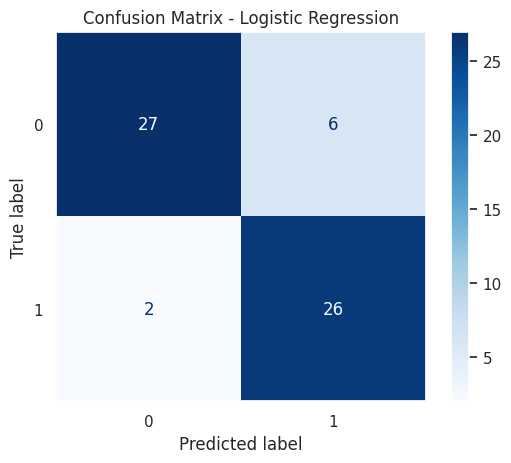

best_models_results: {'Logistic Regression': (219    0
271    0
89     0
101    0
67     0
      ..
285    1
243    1
94     0
291    0
155    1
Name: target, Length: 61, dtype: int64, array([0.2033407 , 0.64710229, 0.07130809, 0.03825581, 0.56313418,
       0.03786157, 0.12720832, 0.22617745, 0.80081688, 0.31856476,
       0.87346916, 0.02005377, 0.09079366, 0.97834135, 0.90111368,
       0.97394194, 0.91969272, 0.30919958, 0.86283014, 0.94163912,
       0.60569325, 0.10871589, 0.79138419, 0.78152945, 0.72704161,
       0.07622933, 0.13460967, 0.97847171, 0.31442707, 0.89924582,
       0.28049702, 0.94516713, 0.78065337, 0.34754898, 0.16057014,
       0.93220487, 0.27889773, 0.32239258, 0.09506326, 0.75502709,
       0.97851877, 0.99701816, 0.97577873, 0.92895448, 0.10521715,
       0.09067794, 0.87881488, 0.04816138, 0.99723492, 0.37125216,
       0.04729979, 0.96808533, 0.66806243, 0.16240577, 0.34212446,
       0.94586858, 0.99317152, 0.55876744, 0.04323701, 0.03034895,
       0.98

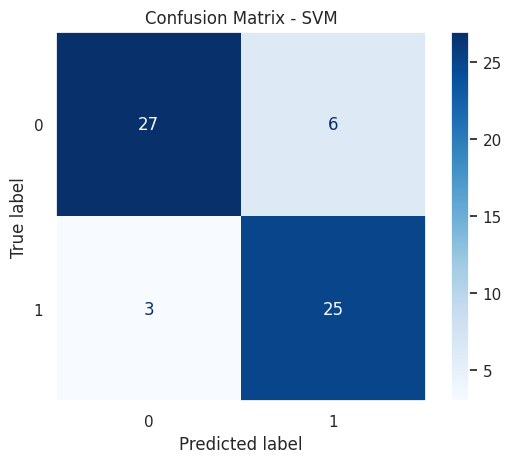

best_models_results: {'Logistic Regression': (219    0
271    0
89     0
101    0
67     0
      ..
285    1
243    1
94     0
291    0
155    1
Name: target, Length: 61, dtype: int64, array([0.2033407 , 0.64710229, 0.07130809, 0.03825581, 0.56313418,
       0.03786157, 0.12720832, 0.22617745, 0.80081688, 0.31856476,
       0.87346916, 0.02005377, 0.09079366, 0.97834135, 0.90111368,
       0.97394194, 0.91969272, 0.30919958, 0.86283014, 0.94163912,
       0.60569325, 0.10871589, 0.79138419, 0.78152945, 0.72704161,
       0.07622933, 0.13460967, 0.97847171, 0.31442707, 0.89924582,
       0.28049702, 0.94516713, 0.78065337, 0.34754898, 0.16057014,
       0.93220487, 0.27889773, 0.32239258, 0.09506326, 0.75502709,
       0.97851877, 0.99701816, 0.97577873, 0.92895448, 0.10521715,
       0.09067794, 0.87881488, 0.04816138, 0.99723492, 0.37125216,
       0.04729979, 0.96808533, 0.66806243, 0.16240577, 0.34212446,
       0.94586858, 0.99317152, 0.55876744, 0.04323701, 0.03034895,
       0.98

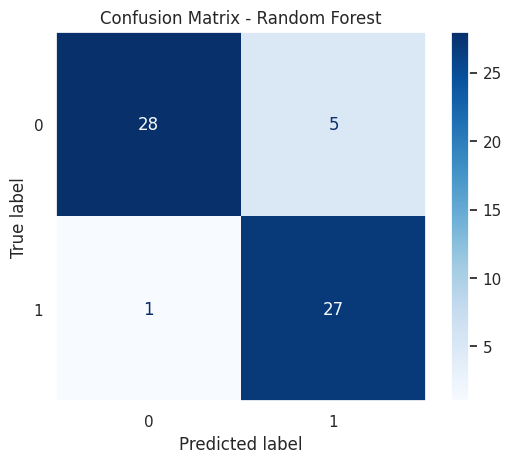

best_models_results: {'Logistic Regression': (219    0
271    0
89     0
101    0
67     0
      ..
285    1
243    1
94     0
291    0
155    1
Name: target, Length: 61, dtype: int64, array([0.2033407 , 0.64710229, 0.07130809, 0.03825581, 0.56313418,
       0.03786157, 0.12720832, 0.22617745, 0.80081688, 0.31856476,
       0.87346916, 0.02005377, 0.09079366, 0.97834135, 0.90111368,
       0.97394194, 0.91969272, 0.30919958, 0.86283014, 0.94163912,
       0.60569325, 0.10871589, 0.79138419, 0.78152945, 0.72704161,
       0.07622933, 0.13460967, 0.97847171, 0.31442707, 0.89924582,
       0.28049702, 0.94516713, 0.78065337, 0.34754898, 0.16057014,
       0.93220487, 0.27889773, 0.32239258, 0.09506326, 0.75502709,
       0.97851877, 0.99701816, 0.97577873, 0.92895448, 0.10521715,
       0.09067794, 0.87881488, 0.04816138, 0.99723492, 0.37125216,
       0.04729979, 0.96808533, 0.66806243, 0.16240577, 0.34212446,
       0.94586858, 0.99317152, 0.55876744, 0.04323701, 0.03034895,
       0.98

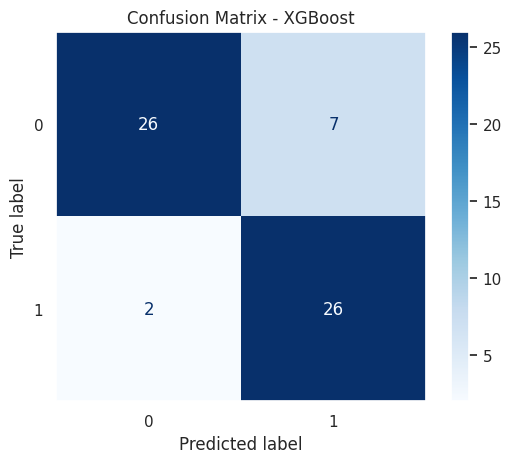

best_models_results: {'Logistic Regression': (219    0
271    0
89     0
101    0
67     0
      ..
285    1
243    1
94     0
291    0
155    1
Name: target, Length: 61, dtype: int64, array([0.2033407 , 0.64710229, 0.07130809, 0.03825581, 0.56313418,
       0.03786157, 0.12720832, 0.22617745, 0.80081688, 0.31856476,
       0.87346916, 0.02005377, 0.09079366, 0.97834135, 0.90111368,
       0.97394194, 0.91969272, 0.30919958, 0.86283014, 0.94163912,
       0.60569325, 0.10871589, 0.79138419, 0.78152945, 0.72704161,
       0.07622933, 0.13460967, 0.97847171, 0.31442707, 0.89924582,
       0.28049702, 0.94516713, 0.78065337, 0.34754898, 0.16057014,
       0.93220487, 0.27889773, 0.32239258, 0.09506326, 0.75502709,
       0.97851877, 0.99701816, 0.97577873, 0.92895448, 0.10521715,
       0.09067794, 0.87881488, 0.04816138, 0.99723492, 0.37125216,
       0.04729979, 0.96808533, 0.66806243, 0.16240577, 0.34212446,
       0.94586858, 0.99317152, 0.55876744, 0.04323701, 0.03034895,
       0.98

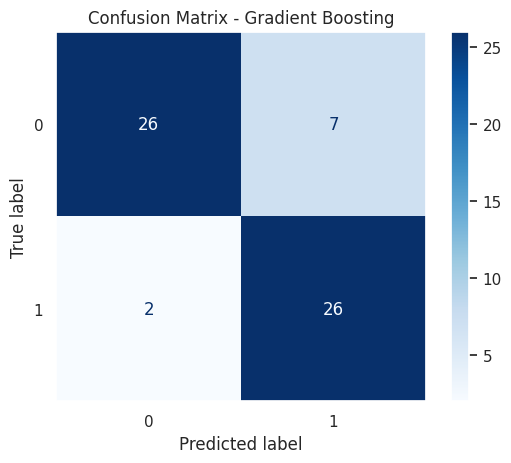

,Model,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_0,F1_1,Macro_Avg_Precision,Macro_Avg_Recall,Macro_Avg_F1,Support
0,Logistic Regression,0.868852,0.931034,0.812500,0.818182,0.928571,0.870968,0.866667,0.871767,0.873377,0.868817,61
1,SVM,0.852459,0.900000,0.806452,0.818182,0.892857,0.857143,0.847458,0.853226,0.855519,0.852300,61
2,Random Forest,0.901639,0.965517,0.843750,0.848485,0.964286,0.903226,0.900000,0.904634,0.906385,0.901613,61
3,XGBoost,0.852459,0.928571,0.787879,0.787879,0.928571,0.852459,0.852459,0.858225,0.858225,0.852459,61
4,Gradient Boosting,0.852459,0.928571,0.787879,0.787879,0.928571,0.852459,0.852459,0.858225,0.858225,0.852459,61


In [113]:
results = []
for model, name in models:
    evaluate_model(model, name)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision_0", "Precision_1",
                                            "Recall_0", "Recall_1", "F1_0", "F1_1",
                                            "Macro_Avg_Precision", "Macro_Avg_Recall",
                                            "Macro_Avg_F1", "Support"])
display(results_df)


In [110]:
# Hyperparameter grids for each model
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }
}

Here we use StratifiedKFold because of the unbalanced data.



Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best model forLogistic Regression:  LogisticRegression(C=0.01, max_iter=10000, random_state=42, solver='liblinear')

===========================Logistic Regression=============================
              precision    recall  f1-score   support

           0       0.96      0.76      0.85        33
           1       0.77      0.96      0.86        28

    accuracy                           0.85        61
   macro avg       0.87      0.86      0.85        61
weighted avg       0.87      0.85      0.85        61



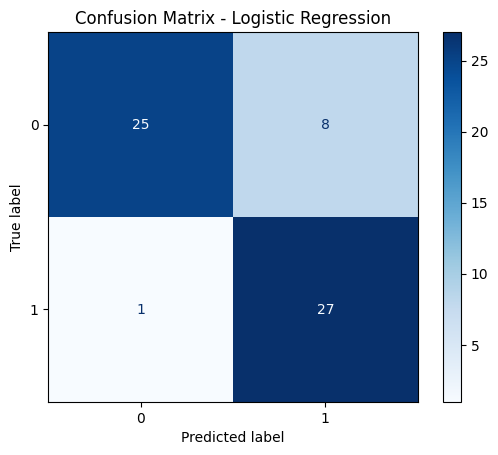



Tuning hyperparameters for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best model forSVM:  SVC(C=1, probability=True, random_state=42)

===========================SVM=============================
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        33
           1       0.78      0.89      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



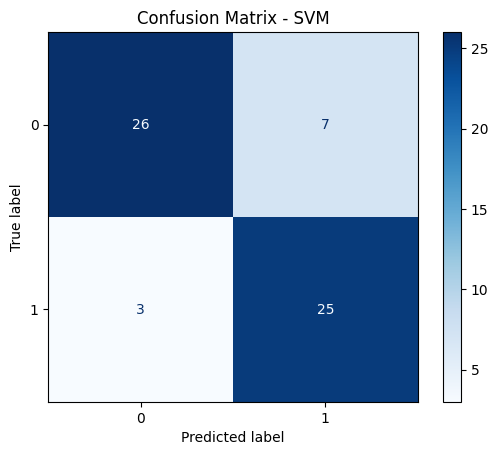



Tuning hyperparameters for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best model forRandom Forest:  RandomForestClassifier(min_samples_split=5, n_estimators=50, random_state=42)

===========================Random Forest=============================
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



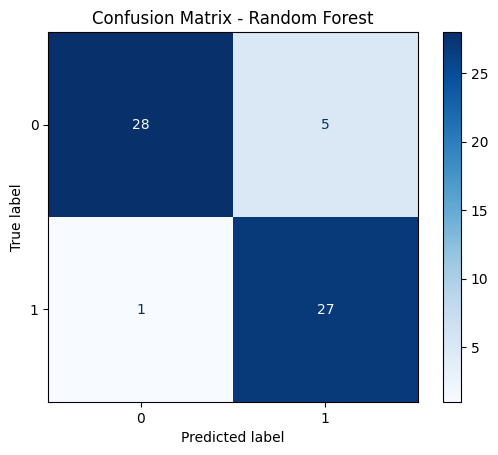



Tuning hyperparameters for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best model forXGBoost:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=

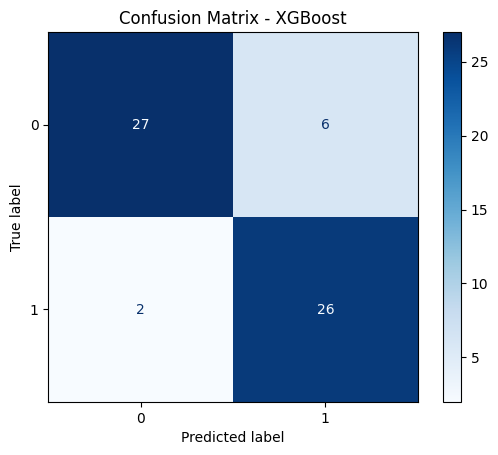



Tuning hyperparameters for Gradient Boosting...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters for Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best model forGradient Boosting:  GradientBoostingClassifier(learning_rate=0.2, max_depth=5, min_samples_leaf=2,
                           n_estimators=200, random_state=42)

===========================Gradient Boosting=============================
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



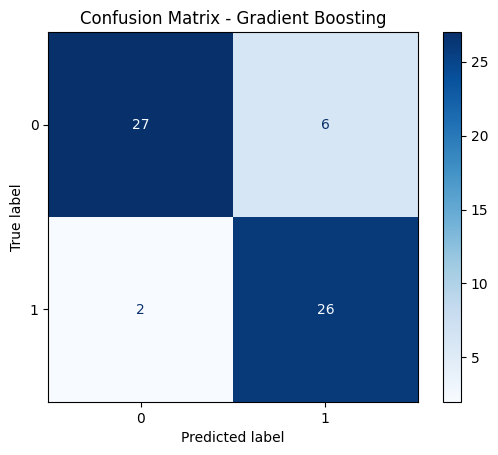

,Model,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1_0,F1_1,Macro_Avg_Precision,Macro_Avg_Recall,Macro_Avg_F1,Support
0,Logistic Regression,0.868852,0.931034,0.812500,0.818182,0.928571,0.870968,0.866667,0.871767,0.873377,0.868817,61
1,SVM,0.852459,0.900000,0.806452,0.818182,0.892857,0.857143,0.847458,0.853226,0.855519,0.852300,61
2,Random Forest,0.901639,0.965517,0.843750,0.848485,0.964286,0.903226,0.900000,0.904634,0.906385,0.901613,61
3,XGBoost,0.852459,0.928571,0.787879,0.787879,0.928571,0.852459,0.852459,0.858225,0.858225,0.852459,61
4,Gradient Boosting,0.852459,0.928571,0.787879,0.787879,0.928571,0.852459,0.852459,0.858225,0.858225,0.852459,61
5,Logistic Regression,0.885246,0.906250,0.862069,0.878788,0.892857,0.892308,0.877193,0.884159,0.885823,0.884750,61
6,SVM,0.885246,0.906250,0.862069,0.878788,0.892857,0.892308,0.877193,0.884159,0.885823,0.884750,61
7,Random Forest,0.901639,0.965517,0.843750,0.848485,0.964286,0.903226,0.900000,0.904634,0.906385,0.901613,61
8,XGBoost,0.868852,0.878788,0.857143,0.878788,0.857143,0.878788,0.857143,0.867965,0.867965,0.867965,61
9,Gradient Boosting,0.868852,0.878788,0.857143,0.878788,0.857143,0.878788,0.857143,0.867965,0.867965,0.867965,61


In [26]:
from sklearn.model_selection import StratifiedKFold

best_tuned_models = {}
# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in models:
    print(f"\n\nTuning hyperparameters for {name}...")

    param_grid = param_grids.get(name, {})

    if param_grid:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='recall',
            cv=cv,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        print(f"Best Parameters for {name}:", grid_search.best_params_)

        # Get the best model
        best_model = grid_search.best_estimator_
        best_tuned_models[name] = grid_search.best_estimator_
        print(f"Best model for{name}: ",best_model)

        evaluate_model(best_model, name)
    else:
        best_tuned_models[name] = model
        evaluate_model(model, name)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision_0", "Precision_1",
                                            "Recall_0", "Recall_1", "F1_0", "F1_1",
                                            "Macro_Avg_Precision", "Macro_Avg_Recall",
                                            "Macro_Avg_F1", "Support"])
display(results_df)

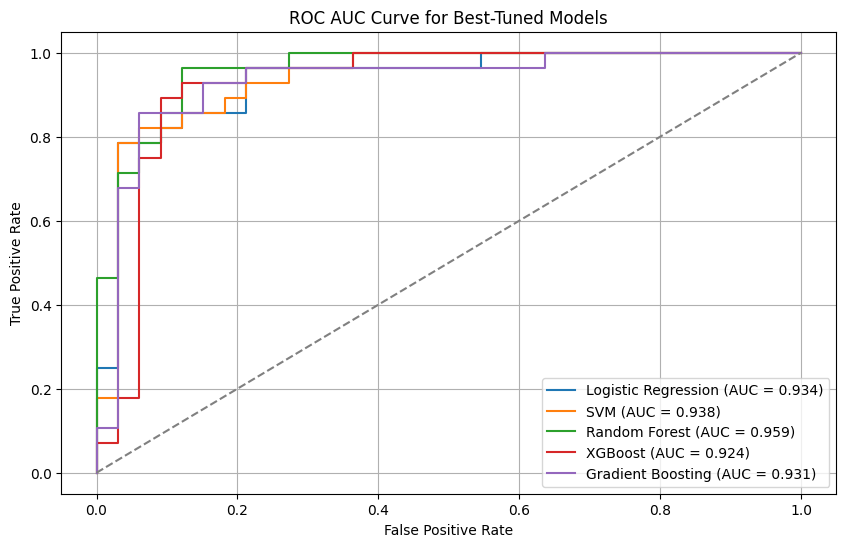

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC Curve
plt.figure(figsize=(10, 6))

for model_name, (y_true, y_pred_proba) in best_models_results.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Plot Random Guess (Baseline)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve for Best-Tuned Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()



Best performing model: Random Forest


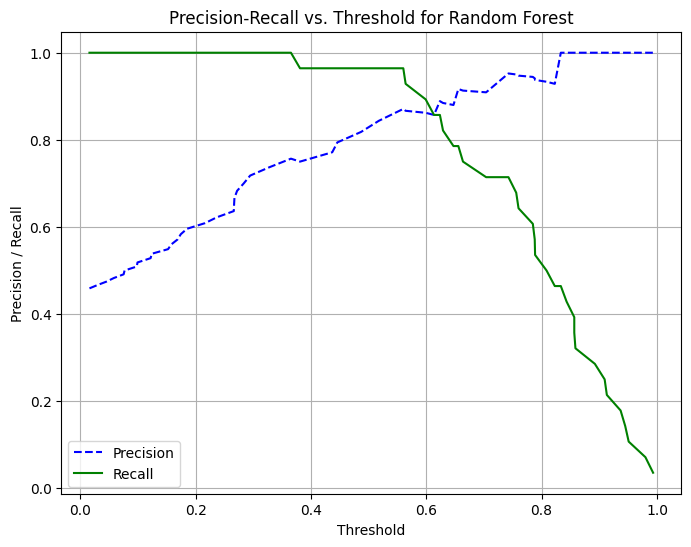

In [28]:
from sklearn.metrics import precision_recall_curve

# Identify the best model based on highest accuracy
best_model_idx = results_df["Accuracy"].idxmax()
best_model_name = results_df.loc[best_model_idx, "Model"]
print(f"\nBest performing model: {best_model_name}")

# Retrieve the best model
best_model = best_tuned_models[best_model_name]

# Get probabilities for the positive class
y_scores = best_models_results[best_model_name][1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision")
plt.plot(thresholds, recall[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.legend(loc="best")
plt.title(f"Precision-Recall vs. Threshold for {best_model_name}")
plt.grid(True)
plt.show()


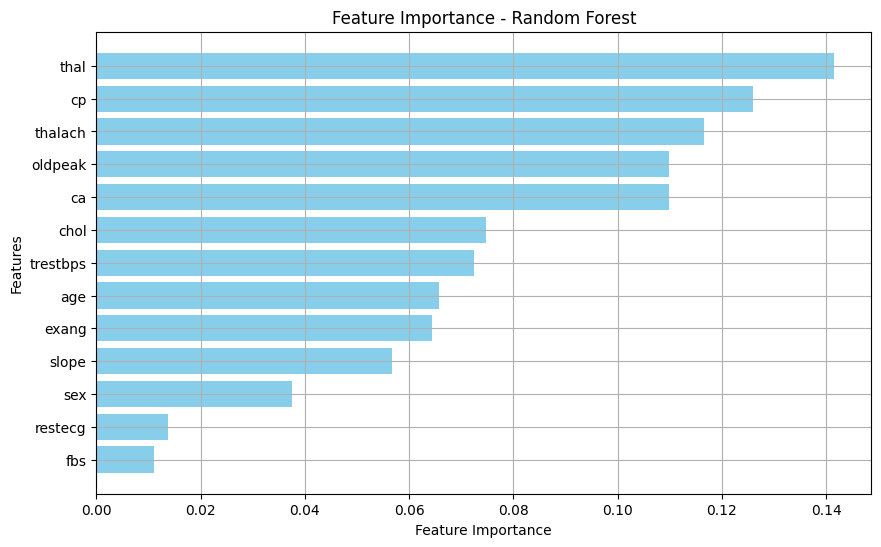


Top Important Features:
     Feature  Importance
12      thal    0.141566
2         cp    0.125870
7    thalach    0.116654
9    oldpeak    0.109833
11        ca    0.109789
4       chol    0.074695
3   trestbps    0.072417
0        age    0.065642
8      exang    0.064396
10     slope    0.056711


In [29]:
# Feature Importance for Best Model (Random Forest)
if hasattr(best_model, "feature_importances_"):
    feature_importance = best_model.feature_importances_
    feature_names = X_train.columns

    # Create DataFrame for visualization
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()

    # Print the top features
    print("\nTop Important Features:")
    print(importance_df.head(10))
